In [ ]:
# Instalación, si es necesario:
# %pip install pygame torch numpy matplotlib

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import deque

from Game import SpikesEnv, DQN, ACTIONS, STATE_SIZE

## 1. Descripción del problema

## Objetivo Principal
Sobrevivir el mayor tiempo posible y acumular puntos rebotando en las paredes y recolectando dulces, mientras evitas tocar cualquier pincho.

## Controles y Movimiento
* **Movimiento:** El desplazamiento horizontal del pájaro es automático.
* **Acción del jugador:** La única acción posible es "aletear", lo cual le da un impulso vertical (hacia arriba) al pájaro para evitar caer o chocar.

## Los Peligros (Pinchos)
Cualquier contacto con un pincho resulta en la **derrota inmediata** (fin del juego).

* **Pinchos de techo y suelo:** Son fijos, tienen el mismo tamaño que los laterales y cubren toda la parte superior e inferior de la pantalla sin sobreponerse.
* **Pinchos laterales:** Aparecen en las paredes (izquierda o derecha). Hay 12 posiciones (slots) verticales posibles.
* **Aparición dinámica:** Cada vez que el pájaro rebota en una pared, los pinchos se regeneran en posiciones aleatorias en la pared opuesta (hacia la que vuela el pájaro).

### Progresión de dificultad (Pinchos laterales)
La cantidad y formación de los pinchos laterales aumenta según la puntuación del jugador:

* **0–4 puntos:** 2 pinchos.
* **5–9 puntos:** 3 pinchos.
* **10–19 puntos:** 4 pinchos.
* **20–34 puntos:** 5 pinchos.
* **35–49 puntos:** 6 pinchos.
* **50 puntos o más:** 7 pinchos.
* **Agrupación:** Si tienes menos de 20 puntos, los pinchos aparecen separados. A partir de los 20 puntos, el juego permite que se formen "bloques" de 2 a 3 pinchos consecutivos.

## Puntuación y Dulces
Ganas **1 punto** por cada vez que logras rebotar en una pared de forma segura. Además, puedes sumar puntos extra recogiendo dulces.

* Solo hay un dulce activo a la vez (en el lado izquierdo o derecho).
* El dulce se mantiene fijo en su lugar hasta que lo recoges; luego aparece uno nuevo.
* Están ubicados a una distancia segura de las paredes para que no se superpongan con los pinchos laterales.

### Tipos de dulces
El color del dulce y los puntos que otorga dependen de tu puntuación actual:

* **0–4 puntos:** Dulce azul (+2 puntos extra).
* **5–9 puntos:** Dulce naranja (+3 puntos extra).
* **10 puntos o más:** Dulce rosa (+4 puntos extra).

## Niveles visuales y Modificadores
* El fondo del juego va cambiando de color por franjas de puntuación.
* **Modo de alta dificultad:** Al alcanzar los 100 puntos, el escenario cambia drásticamente: el fondo se vuelve negro, los pinchos se vuelven rojos, y la velocidad horizontal del pájaro disminuye, alterando el ritmo del juego.

In [3]:
# Entorno
env = SpikesEnv(render=False)
n_states = STATE_SIZE
n_actions = len(ACTIONS)

print("Estados (dimensión):", n_states)
print("Acciones:", n_actions, ACTIONS)

Estados (dimensión): 10
Acciones: 2 [0, 1]


## 2. Agente base aleatorio

Política uniforme sobre las acciones. Sirve como línea base antes de entrenar.

In [4]:
n_random = 100
max_steps = 1500
random_rewards = []
random_scores = []
random_steps = []

for _ in range(n_random):
    state = env.reset()
    total_r, steps = 0.0, 0
    while True:
        action = random.choice(ACTIONS)
        state, reward, done = env.step(action)
        total_r += reward
        steps += 1
        if done or steps >= max_steps:
            break
    random_rewards.append(total_r)
    random_scores.append(env.score)
    random_steps.append(steps)

print("=== Agente aleatorio ===")
print(f"Reward media: {np.mean(random_rewards):.2f}")
print(f"Score medio:  {np.mean(random_scores):.2f}")
print(f"Pasos medios: {np.mean(random_steps):.1f}")
print(f"Episodios fallidos (score=0): {(np.array(random_scores) == 0).sum()} / {n_random}")

=== Agente aleatorio ===
Reward media: -9.31
Score medio:  0.30
Pasos medios: 39.6
Episodios fallidos (score=0): 86 / 100


## 3. Deep Q-Learning (DQN)

Como el estado es continuo, se usa DQN:

1. Red MLP que estima Q(s, a).
2. Experience replay.
3. Red objetivo (`target_model`).
4. Exploración ε-greedy con decaimiento.
5. Pérdida MSE con target de Bellman.

In [5]:
# Descripción de DQN y su arquitectura (desde Game.py: capas 128)
model = DQN(n_states, n_actions)
target_model = DQN(n_states, n_actions)
target_model.load_state_dict(model.state_dict())

optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

memory = deque(maxlen=50000)

gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

episodes = 800
batch_size = 64
target_update = 20

rewards_history = []
scores_history = []

In [6]:
# Entrenamiento
def choose_action(state, epsilon):
    if random.random() < epsilon:
        return random.choice(ACTIONS)

    state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        q_values = model(state_tensor)
    return int(torch.argmax(q_values).item())


def train_step():
    if len(memory) < batch_size:
        return

    batch = random.sample(memory, batch_size)
    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.tensor(np.array(states), dtype=torch.float32)
    next_states = torch.tensor(np.array(next_states), dtype=torch.float32)
    actions = torch.tensor(actions, dtype=torch.long)
    rewards = torch.tensor(rewards, dtype=torch.float32)
    dones = torch.tensor(dones, dtype=torch.float32)

    q_values = model(states)
    q_value = q_values.gather(1, actions.unsqueeze(1)).squeeze()

    with torch.no_grad():
        next_q_values = target_model(next_states)
        max_next_q = torch.max(next_q_values, dim=1)[0]
        target = rewards + gamma * max_next_q * (1 - dones)

    loss = loss_fn(q_value, target)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

In [7]:
# Ejecución
for episode in range(episodes):
    state = env.reset()
    total_reward = 0.0
    steps = 0

    while True:
        action = choose_action(state, epsilon)
        next_state, reward, done = env.step(action)
        memory.append((state, action, reward, next_state, float(done)))
        state = next_state
        total_reward += reward
        train_step()
        steps += 1
        if done or steps >= max_steps:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    if episode % target_update == 0:
        target_model.load_state_dict(model.state_dict())

    rewards_history.append(total_reward)
    scores_history.append(env.score)

    if episode % 100 == 0:
        avg_reward = np.mean(rewards_history[-100:])
        print(
            f"Episodio {episode} | "
            f"Recompensa promedio: {avg_reward:.3f} | "
            f"Score promedio: {np.mean(scores_history[-100:]):.2f} | "
            f"Epsilon: {epsilon:.3f}"
        )

Episodio 0 | Recompensa promedio: -9.610 | Score promedio: 0.00 | Epsilon: 0.995
Episodio 100 | Recompensa promedio: -9.252 | Score promedio: 0.36 | Epsilon: 0.603
Episodio 200 | Recompensa promedio: -9.191 | Score promedio: 0.39 | Epsilon: 0.365
Episodio 300 | Recompensa promedio: -8.813 | Score promedio: 0.74 | Epsilon: 0.221
Episodio 400 | Recompensa promedio: -8.404 | Score promedio: 0.96 | Epsilon: 0.134
Episodio 500 | Recompensa promedio: -7.553 | Score promedio: 1.55 | Epsilon: 0.081
Episodio 600 | Recompensa promedio: -7.356 | Score promedio: 1.42 | Epsilon: 0.050
Episodio 700 | Recompensa promedio: -6.521 | Score promedio: 2.04 | Epsilon: 0.050


## 4. Experimentos con hiperparámetros

Se modifican al menos tres: tasa de aprendizaje (`lr`), factor de descuento (`gamma`) y decaimiento de exploración (`epsilon_decay`).

In [8]:
def run_training(lr, gamma_val, eps_decay, n_episodes=400):
    local_model = DQN(n_states, n_actions)
    local_target = DQN(n_states, n_actions)
    local_target.load_state_dict(local_model.state_dict())
    opt = optim.Adam(local_model.parameters(), lr=lr)
    mem = deque(maxlen=50000)
    eps = 1.0
    hist = []

    def act(state, eps):
        if random.random() < eps:
            return random.choice(ACTIONS)
        with torch.no_grad():
            q = local_model(torch.tensor(state, dtype=torch.float32).unsqueeze(0))
        return int(torch.argmax(q).item())

    def learn():
        if len(mem) < batch_size:
            return
        batch = random.sample(mem, batch_size)
        s, a, r, ns, d = zip(*batch)
        s = torch.tensor(np.array(s), dtype=torch.float32)
        ns = torch.tensor(np.array(ns), dtype=torch.float32)
        a = torch.tensor(a, dtype=torch.long)
        r = torch.tensor(r, dtype=torch.float32)
        d = torch.tensor(d, dtype=torch.float32)
        q = local_model(s).gather(1, a.unsqueeze(1)).squeeze()
        with torch.no_grad():
            tgt = r + gamma_val * torch.max(local_target(ns), dim=1)[0] * (1 - d)
        loss = loss_fn(q, tgt)
        opt.zero_grad()
        loss.backward()
        opt.step()

    for ep in range(n_episodes):
        state = env.reset()
        total = 0.0
        steps = 0
        while True:
            action = act(state, eps)
            next_state, reward, done = env.step(action)
            mem.append((state, action, reward, next_state, float(done)))
            state = next_state
            total += reward
            learn()
            steps += 1
            if done or steps >= max_steps:
                break
        eps = max(epsilon_min, eps * eps_decay)
        if ep % target_update == 0:
            local_target.load_state_dict(local_model.state_dict())
        hist.append(env.score)

    return float(np.mean(hist[-100:])), local_model


experiments = [
    ("base", 0.001, 0.99, 0.995),
    ("lr_alto", 0.005, 0.99, 0.995),
    ("gamma_bajo", 0.001, 0.90, 0.995),
    ("eps_lento", 0.001, 0.99, 0.999),
]

print(f"{'nombre':12} {'lr':8} {'gamma':6} {'eps_decay':10} {'score_ult100':12}")
print("-" * 55)
for name, lr, g, ed in experiments:
    score_avg, _ = run_training(lr, g, ed)
    print(f"{name:12} {lr:<8} {g:<6} {ed:<10} {score_avg:<12.2f}")

nombre       lr       gamma  eps_decay  score_ult100
-------------------------------------------------------
base         0.001    0.99   0.995      0.93        
lr_alto      0.005    0.99   0.995      1.25        
gamma_bajo   0.001    0.9    0.995      1.16        
eps_lento    0.001    0.99   0.999      0.29        


## 5. Visualización y análisis

Curva de recompensa promedio móvil y comparación numérica random vs DQN.

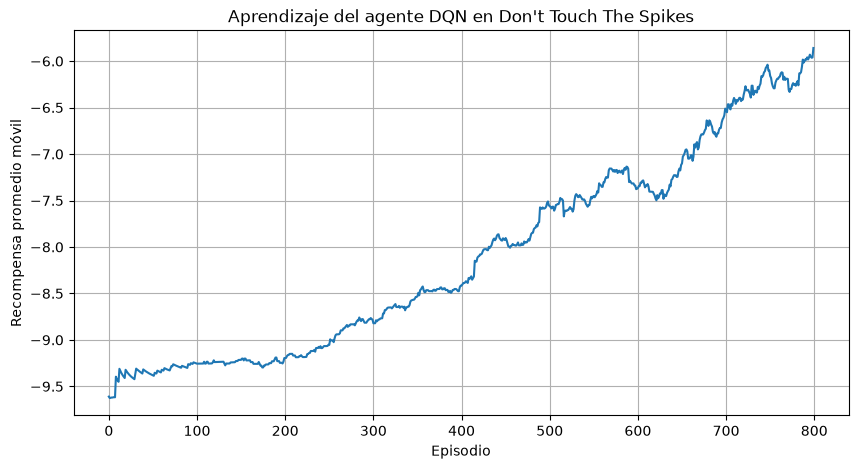

In [9]:
# Gráfica de aprendizaje
window = 100
moving_avg = [
    np.mean(rewards_history[max(0, i - window) : i + 1])
    for i in range(len(rewards_history))
]

plt.figure(figsize=(10, 5))
plt.plot(moving_avg)
plt.title("Aprendizaje del agente DQN en Don't Touch The Spikes")
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio móvil")
plt.grid(True)
plt.show()

In [10]:
# Evaluación del agente entrenado (ε = 0)
eval_rewards = []
eval_scores = []

for _ in range(50):
    state = env.reset()
    total_r, steps = 0.0, 0
    while True:
        action = choose_action(state, epsilon=0.0)
        state, reward, done = env.step(action)
        total_r += reward
        steps += 1
        if done or steps >= max_steps:
            break
    eval_rewards.append(total_r)
    eval_scores.append(env.score)

print("Random  | reward media:", round(np.mean(random_rewards), 2), "| score medio:", round(np.mean(random_scores), 2))
print("DQN     | reward media:", round(np.mean(eval_rewards), 2), "| score medio:", round(np.mean(eval_scores), 2))
print("Score máx DQN:", max(eval_scores))

Random  | reward media: -9.31 | score medio: 0.3
DQN     | reward media: -3.78 | score medio: 3.7
Score máx DQN: 12


### Análisis de Resultados

* **Progreso del agente:** El agente que se mueve al azar pierde rápidamente. En contraste, el modelo **DQN** mejora su puntuación promedio conforme avanza el entrenamiento (gracias a que reduce sus movimientos aleatorios, representados por `ε`, y aprende al repasar experiencias pasadas).
* **Fluctuaciones en el aprendizaje:** Como la posición de los pinchos laterales es impredecible, el entorno cambia constantemente en cada partida. Esto provoca que el progreso del agente no sea una línea recta perfecta, sino que la curva de aprendizaje muestre subidas y bajadas (oscilaciones).
* **Impacto de los hiperparámetros:**
  * Un valor bajo de **gamma (`γ`)** hace que el agente se enfoque solo en sobrevivir a corto plazo, perdiendo la visión a futuro.
  * Una **tasa de aprendizaje (`lr`)** demasiado alta vuelve inestable el proceso, dificultando que el agente logre aprender de manera constante.

## 6. Conclusión Crítica

### Logros del Aprendizaje
El agente logra evolucionar desde un comportamiento errático y aleatorio hacia una estrategia donde utiliza el aleteo de forma consciente para esquivar los pinchos, rebotar en las paredes y recolectar dulces. El uso del algoritmo DQN resulta muy adecuado debido a que las variables del juego (posiciones, velocidades) son continuas.

### Limitaciones Identificadas
* **Visión limitada:** El modelo actual resume la información de los pinchos laterales en lugar de observar las 12 posiciones exactas, lo que le quita precisión.
* **Tiempo de entrenamiento:** Con pocos episodios, al agente le cuesta estabilizarse y lograr puntuaciones altas de manera consistente.
* **Balance de recompensas (Reward Shaping):** La gran diferencia entre la recompensa por sobrevivir (+0.01) y el castigo por chocar (-10) tiene un impacto drástico en cómo el agente toma sus decisiones, volviéndolo a veces demasiado conservador.

### Posibles Mejoras Futuras
* **Algoritmos más avanzados:** Implementar mejoras sobre DQN, como *Double/Dueling DQN* o *Prioritized Experience Replay*.
* **Aprendizaje progresivo (Curriculum Learning):** Entrenar al agente aumentando la dificultad poco a poco, empezando con muy pocos pinchos y sumando más a medida que mejora.

> **Demo visual:** Para ver el entorno en acción, ejecuta `python Game.py` en la terminal.

In [11]:
env.close()